In [1]:
import pandas as pd
import sqlalchemy as sa
import numpy as np
from pathlib import Path
from sqlalchemy import inspect, text
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from great_tables import GT, loc

sqlite_path = "Database/DB_results.db"



engine = sa.create_engine(f"sqlite:///{sqlite_path}")

# Verbindung kurz testen
with engine.connect() as conn:
    conn.execute(text("SELECT 1"))

inspector = inspect(engine)
table_names = inspector.get_table_names()

print("Tabellen in der Datenbank:")
for table_name in table_names:
    print(table_name)

Tabellen in der Datenbank:
CatBoost
ConfidenceIntervals
Gandalf
LightGBM
Logistic Regression
Multilayer Perceptron
TabNet
XGBoost
model_results


In [2]:
sqlite_path = "Database/DB_results.db"
engine = sa.create_engine("sqlite:///" + sqlite_path)
engine.connect()


df=pd.read_sql("SELECT * FROM ConfidenceIntervals", con=engine)

from pathlib import Path

print(Path.cwd())



df.to_excel(f"{Path.cwd()}/ConfidenceIntervals.xlsx", index=False)


df.head()

/home/jrech/predictive-goods-receipt-scheduling


,Model,metric,mean_bootstrap,std_bootstrap,ci_lower_95,ci_upper_95
0,Logistic Regression,accuracy_weighted,0.4592,0.0100,0.4402,0.4791
1,Logistic Regression,mean_absolute_error_weighted,0.9377,0.0208,0.8965,0.9790
2,Logistic Regression,f1_weighted,0.4402,0.0104,0.4206,0.4611
3,Logistic Regression,precision_weighted,0.4366,0.0105,0.4168,0.4574
4,Logistic Regression,recall_weighted,0.4592,0.0100,0.4402,0.4791


Plotting metric: accuracy_weighted
Model order: Accuracy


ValueError: Categorical categories must be unique

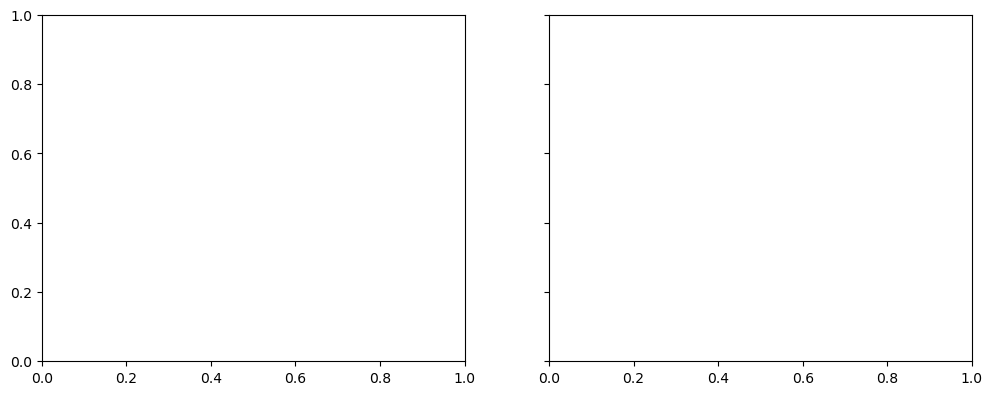

In [3]:





metrics = {
    "accuracy_weighted": "Accuracy",
    "f1_weighted": "F1-Score",
    "MAE": "MAE"
    
}

order_df = df[df["metric"] == "accuracy_weighted"].copy()
order_df = order_df.sort_values("mean_bootstrap", ascending=True)
model_order = order_df["Model"].tolist()


y_pos = np.arange(len(model_order))



fig, axes = plt.subplots(
    ncols=2,
    figsize=(12, 4.5),
    sharey=True
)




for ax, (metric, xlabel) in zip(axes, metrics.items()):
    print(f"Plotting metric: {metric}")
    print(f"Model order: {xlabel}")

    plot_df = df[df["metric"] == metric].copy()
    plot_df["Model"] = pd.Categorical(
        plot_df["Model"],
        categories=model_order,
        ordered=True
    )
    plot_df = plot_df.sort_values("Model").reset_index(drop=True)

    xerr_lower = plot_df["mean_bootstrap"] - plot_df["ci_lower_95"]
    xerr_upper = plot_df["ci_upper_95"] - plot_df["mean_bootstrap"]
    xerr = [xerr_lower, xerr_upper]
    

    ax.hlines(
        y=y_pos,
        xmin=plot_df["ci_lower_95"].min() - 0.02,
        xmax=plot_df["mean_bootstrap"],
        color="lightgray",
        alpha=0.8,
        linewidth=2
    )

  
    ax.errorbar(
        x=plot_df["mean_bootstrap"],
        y=y_pos,
        xerr=xerr,
        fmt="o",
        capsize=4,
        linewidth=1.5,
        markersize=6
    )


    for i, row in plot_df.iterrows():
        ax.text(
            row["ci_upper_95"] + 0.004,
            i,
            f'{row["mean_bootstrap"]:.3f} '
            f'[{row["ci_lower_95"]:.3f}; {row["ci_upper_95"]:.3f}]',
            va="center",
            fontsize=12,
            fontweight="bold" if row["Model"] == "LightGBM" else "normal"
        )

    ax.set_xlabel(xlabel, fontsize=12)
    ax.grid(axis="x", linestyle="--", alpha=0.5)

    ax.set_xlim(
        plot_df["ci_lower_95"].min() - 0.02,
        plot_df["ci_upper_95"].max() + 0.12
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(model_order, fontsize=12)
axes[0].set_ylabel("Modellpipeline")






plt.tight_layout()
plt.show()




In [ ]:



df=pd.read_sql("SELECT * FROM model_results", con=engine)


model_name           str
accuracy         float64
roc_auc              str
precision            str
recall               str
f1_score             str
training_time        str
timestamp            str
rank             float64
rank_overall     float64
dtype: object

In [ ]:


df=df[df["timestamp"].str.contains("2026-05-26")]
df["rank"] = df.groupby(df.columns[0])["accuracy"].rank(ascending=False, method="first")
df=df.sort_values(by=["accuracy"], ascending=False)

df=df[df!="None"].fillna(0)
df=df[df["rank"]==1]
df=df.copy()
df.iloc[:,1:-1] = df.iloc[:,1:-1].astype(str)
df.iloc[:,1:-1]= df.iloc[:,1:-1]+"0"
df.iloc[:,1:-1] = df.iloc[:,1:-1].apply(lambda col: col.str[:6])


df=df.drop(columns=["rank", "timestamp","rank_overall"])

df.columns = [
    "Model",
    "Accuracy",
    "MAE",
    "ROC-AUC",
    "Precision",
    "Recall",
    "F1-Score",
    "Training Time (s)"
]

df.reset_index(drop=True)

df = df.reset_index(drop=True)

from great_tables import GT, loc, style

df = df.reset_index(drop=True)

gt_tbl = (
    GT(df)




    .tab_style(
        style=[
            style.text(size="30px", weight="bold")
        ],
        locations=loc.title())
 

    .tab_style(
        style=[
            style.text(size="25px"),
            style.text(weight="bold")
        ],
        locations=loc.column_labels()
    )
        .tab_style(
        style=[
            style.text(size="25px"),

        ],
        locations=loc.body()
    )

    # 👉 NOCH BREITER
    .cols_width(
        **{col: "150px" for col in df.columns if col != "Training Time (s)" and col != "Model"},
    )

    # Ausrichtung
    .cols_align(
        align="center",
        columns=[col for col in df.columns if col != "Model"]
    )
    .cols_align(
        align="left",
        columns=["Model"]
    )
)

gt_tbl



KeyError: 'timestamp'